# Spectral distance

The raw combinatorial Laplacian is $L=D-A$. The frequency-resolved distance is

$$
d_{\Omega,\eta}(i,j)
=\left[
\sum_{k=2}^{n}
\frac{[\psi_k(i)-\psi_k(j)]^2}
{(\lambda_k-\Omega)^2+\eta^2}
\right]^{1/2}.
$$

$\Omega$ and $\eta$ stay in the same units as the combinatorial-Laplacian eigenvalues. The zero mode cancels in node differences.

The ring and tree examples use bandwidths adapted to their different spectral ranges.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from scipy.cluster.hierarchy import fcluster, linkage

Matplotlib is building the font cache; this may take a moment.


In [2]:
FIGURE_DIR = Path("figures") / "spectral_distance"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RING_OMEGAS = np.array([0.5, 3.0, 7.0])
RING_ETA = 0.25

RING_COUNT = 5
CLIQUE_SIZE = 7

TREE_BRANCHING = 2
TREE_DEPTH = 4
TREE_OMEGAS = [0.5, 1.5, 4.5]
TREE_ETA = 0.15
TREE_REFERENCE_NODE = 6

CMAP = "plasma"
WINDOW_COLOURS = ["#0072B2", "#D55E00", "#009E73"]

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
})

Average-linkage clustering is applied directly to the pairwise distance matrix.

In [3]:
def graph_eigensystem(graph, nodes):
    laplacian = nx.laplacian_matrix(graph, nodelist=nodes).toarray()
    eigenvalues, eigenvectors = np.linalg.eigh(laplacian)
    return eigenvalues, eigenvectors


def spectral_distance(eigenvalues, eigenvectors, omega, eta):
    # The constant mode cancels exactly; dropping it also removes numerical noise.
    keep = eigenvalues > 1e-12
    values = eigenvalues[keep]
    vectors = eigenvectors[:, keep]
    weights = 1 / ((values - omega) ** 2 + eta**2)

    # Keep the kernel construction explicit for comparison with the README equation.
    kernel = (vectors * weights) @ vectors.T
    diagonal = np.diag(kernel)
    squared = diagonal[:, None] + diagonal[None, :] - 2 * kernel
    return np.sqrt(np.maximum(squared, 0))


def adjusted_rand_index(true_labels, predicted_labels):
    _, true_labels = np.unique(true_labels, return_inverse=True)
    _, predicted_labels = np.unique(predicted_labels, return_inverse=True)

    table = np.zeros(
        (true_labels.max() + 1, predicted_labels.max() + 1),
        dtype=int,
    )
    np.add.at(table, (true_labels, predicted_labels), 1)

    def pair_count(values):
        return np.sum(values * (values - 1) // 2)

    observed = pair_count(table)
    rows = pair_count(table.sum(axis=1))
    columns = pair_count(table.sum(axis=0))
    total = len(true_labels) * (len(true_labels) - 1) / 2
    expected = rows * columns / total
    maximum = (rows + columns) / 2

    if np.isclose(maximum, expected):
        return 1.0
    return (observed - expected) / (maximum - expected)


def cluster_distance(distance, cluster_count):
    upper_triangle = distance[np.triu_indices_from(distance, k=1)]
    tree = linkage(upper_triangle, method="average")
    return fcluster(tree, cluster_count, criterion="maxclust") - 1

## Ring of cliques

Five cliques of seven nodes form a ring. Three spectral centres probe when the planted clique organization is visible in the distance.

In [4]:
ring_graph = nx.ring_of_cliques(RING_COUNT, CLIQUE_SIZE)
ring_nodes = list(ring_graph)
ring_labels = np.repeat(np.arange(RING_COUNT), CLIQUE_SIZE)
ring_position = nx.kamada_kawai_layout(ring_graph)
ring_eigenvalues, ring_eigenvectors = graph_eigensystem(ring_graph, ring_nodes)

For the ring of cliques, the spectral weight is

$$
g_{\Omega,\eta}(\lambda)
=\frac{\eta^2}{(\lambda-\Omega)^2+\eta^2}.
$$

The maximum occurs at $\lambda=\Omega$. Short marks on the horizontal axis denote the non-zero combinatorial-Laplacian eigenvalues $\lambda_k$.

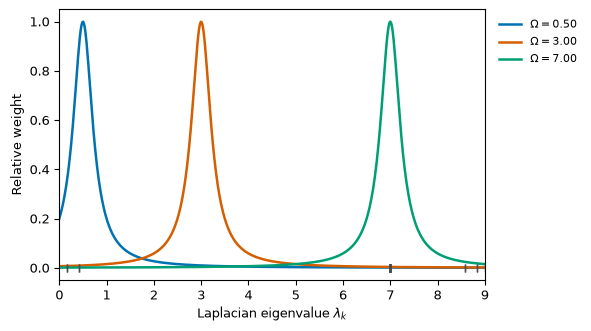

In [5]:
x = np.linspace(0, ring_eigenvalues[-1], 500)

fig, axis = plt.subplots(figsize=(5.8, 3.2), constrained_layout=True)
for omega, colour in zip(RING_OMEGAS, WINDOW_COLOURS):
    weight = RING_ETA**2 / ((x - omega) ** 2 + RING_ETA**2)
    axis.plot(
        x,
        weight,
        color=colour,
        linewidth=1.8,
        label=fr"$\Omega={omega:.2f}$",
    )

nonzero = ring_eigenvalues[ring_eigenvalues > 1e-12]
axis.plot(nonzero, np.zeros_like(nonzero), "|", color="0.30")
axis.set(
    xlabel=r"Laplacian eigenvalue $\lambda_k$",
    ylabel="Relative weight",
    xlim=(0, ring_eigenvalues[-1]),
)
axis.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1.0))
fig.savefig(FIGURE_DIR / "spectral_windows.png", dpi=200)
plt.show()

*Figure 1. Spectral weights $g_{\Omega,\eta}(\lambda)$ for $\Omega=0.5$, $3.0$, and $7.0$, with $\eta=0.25$. Axis marks show the raw combinatorial-Laplacian eigenvalues $\lambda_k$.*

Node 0 is the reference. Node $j$ is coloured by

$$
d_{\Omega,\eta}(0,j).
$$

A shared colour scale permits comparison across the three values of $\Omega$.

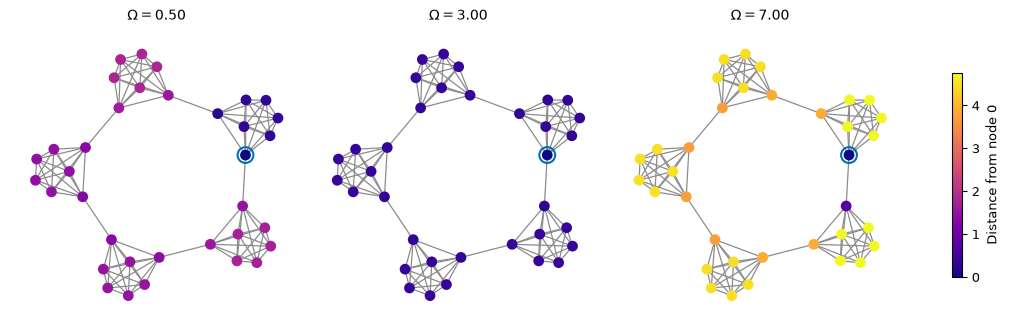

In [6]:
reference_node = 0
ring_distances = [
    spectral_distance(ring_eigenvalues, ring_eigenvectors, omega, RING_ETA)
    for omega in RING_OMEGAS
]
maximum_distance = max(
    distance[reference_node].max()
    for distance in ring_distances
)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2), constrained_layout=True)
for axis, omega, distance in zip(axes, RING_OMEGAS, ring_distances):
    nx.draw_networkx_edges(
        ring_graph,
        ring_position,
        ax=axis,
        edge_color="0.55",
        width=0.9,
    )
    node_plot = nx.draw_networkx_nodes(
        ring_graph,
        ring_position,
        ax=axis,
        node_color=distance[reference_node],
        cmap=CMAP,
        vmin=0,
        vmax=maximum_distance,
        node_size=60,
        linewidths=0,
    )
    axis.scatter(
        *ring_position[reference_node],
        s=130,
        facecolors="none",
        edgecolors="#0072B2",
        linewidths=1.5,
    )
    axis.set_title(fr"$\Omega={omega:.2f}$")
    axis.set_axis_off()

fig.colorbar(node_plot, ax=axes, shrink=0.70, label="Distance from node 0")
fig.savefig(FIGURE_DIR / "ring_distances.png", dpi=200)
plt.show()

*Figure 2. Reference-node distance $d_{\Omega,\eta}(0,j)$ on the ring of cliques for $\Omega=0.5$, $3.0$, and $7.0$, with $\eta=0.25$. The outlined node is $j=0$.*

Let $\widehat c_{\Omega}(i)$ be the five-cluster assignment obtained by average-linkage clustering of $d_{\Omega,\eta}$. The recovery score is

$$
\operatorname{ARI}(\Omega)
=\operatorname{ARI}\!\left(c_{\mathrm{true}},\widehat c_{\Omega}\right),
$$

where $c_{\mathrm{true}}$ contains the five planted clique labels. The sweep covers the raw combinatorial-Laplacian spectrum. A score of one means exact recovery; values near zero indicate chance-level agreement.

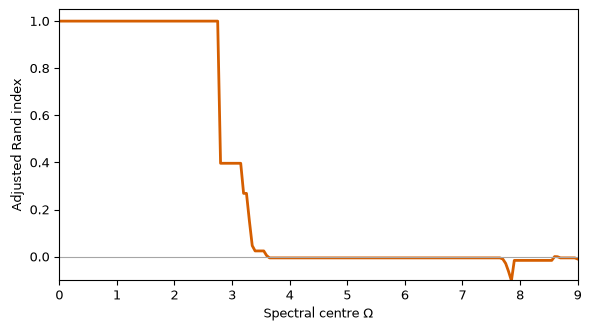

In [7]:
omega_sweep = np.linspace(0, ring_eigenvalues[-1], 181)
clustering_scores = np.array([
    adjusted_rand_index(
        ring_labels,
        cluster_distance(
            spectral_distance(
                ring_eigenvalues,
                ring_eigenvectors,
                omega,
                RING_ETA,
            ),
            RING_COUNT,
        ),
    )
    for omega in omega_sweep
])

fig, axis = plt.subplots(figsize=(5.8, 3.2), constrained_layout=True)
axis.plot(
    omega_sweep,
    clustering_scores,
    color="#D55E00",
    linewidth=2,
)
axis.axhline(0, color="0.65", linewidth=0.8)
axis.set(
    xlabel=r"Spectral centre $\Omega$",
    ylabel="Adjusted Rand index",
    xlim=(0, ring_eigenvalues[-1]),
    ylim=(-0.1, 1.05),
)
fig.savefig(FIGURE_DIR / "clique_recovery.png", dpi=200)
plt.show()

*Figure 3. Clique-recovery score $\operatorname{ARI}(\Omega)$ for $0\leq\Omega\leq\lambda_{\max}=9$, using the raw combinatorial-Laplacian spectrum and $\eta=0.25$.*

## Binary tree

A binary tree of depth four provides a contrasting geometry. Node 6 is the reference.

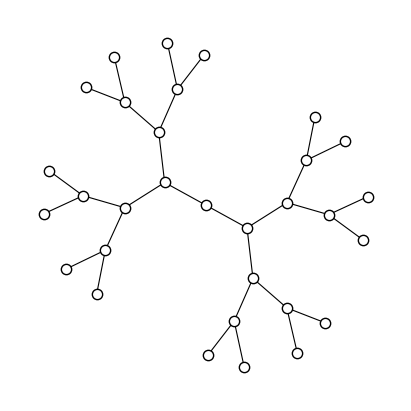

In [8]:
tree_graph = nx.balanced_tree(TREE_BRANCHING, TREE_DEPTH)
tree_nodes = sorted(tree_graph)
tree_position = nx.kamada_kawai_layout(tree_graph)
tree_eigenvalues, tree_eigenvectors = graph_eigensystem(
    tree_graph,
    tree_nodes,
)

fig, axis = plt.subplots(figsize=(4, 4), constrained_layout=True)
nx.draw(
    tree_graph,
    tree_position,
    ax=axis,
    node_size=55,
    with_labels=False,
    node_color="white",
    edgecolors="black",
    width=0.8,
)
fig.savefig(FIGURE_DIR / "binary_tree.png", dpi=200)
plt.show()

*Figure 4. Binary tree with branching factor 2, depth 4, and 31 nodes.*

For each $\Omega$, the tree distance is divided by the largest pairwise value,

$$
\widehat d_{\Omega,\eta}(i,j)
=\frac{d_{\Omega,\eta}(i,j)}
{\max_{u,v}d_{\Omega,\eta}(u,v)}.
$$

The matrix $\widehat d_{\Omega,\eta}(i,j)$ and the reference-node values $\widehat d_{\Omega,\eta}(6,j)$ use the same scale.

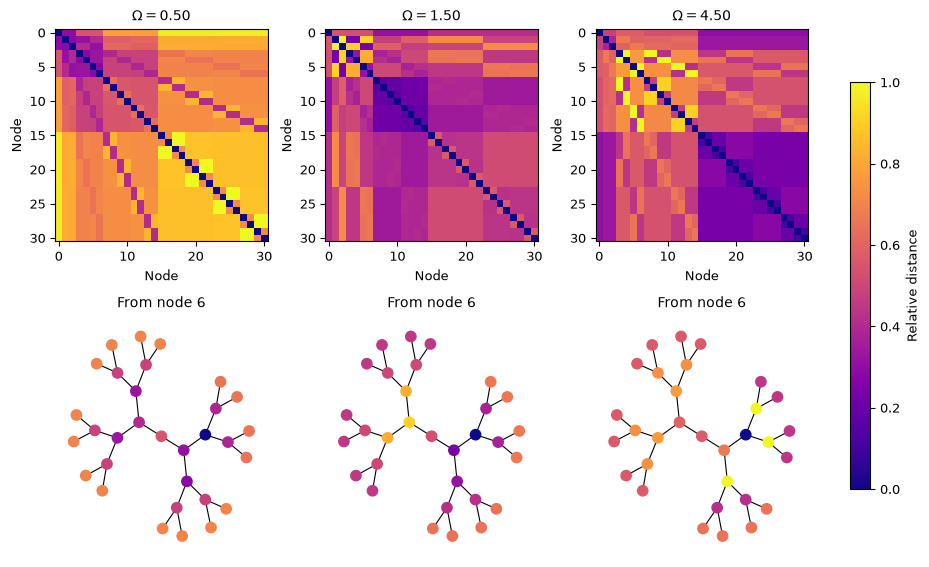

In [9]:
fig, axes = plt.subplots(
    2,
    len(TREE_OMEGAS),
    figsize=(9.2, 5.6),
    constrained_layout=True,
    squeeze=False,
)

for column, omega in enumerate(TREE_OMEGAS):
    relative_distance = spectral_distance(
        tree_eigenvalues,
        tree_eigenvectors,
        omega,
        TREE_ETA,
    )
    relative_distance /= relative_distance.max()

    image = axes[0, column].imshow(
        relative_distance,
        vmin=0,
        vmax=1,
        cmap=CMAP,
    )
    axes[0, column].set_title(fr"$\Omega={omega:.2f}$")
    axes[0, column].set(xlabel="Node", ylabel="Node")

    nx.draw(
        tree_graph,
        tree_position,
        ax=axes[1, column],
        node_size=55,
        with_labels=False,
        node_color=relative_distance[TREE_REFERENCE_NODE],
        cmap=CMAP,
        vmin=0,
        vmax=1,
        width=0.8,
    )
    axes[1, column].set_title(f"From node {TREE_REFERENCE_NODE}")

fig.colorbar(image, ax=axes, label="Relative distance", shrink=0.75)
fig.savefig(FIGURE_DIR / "tree_distances.png", dpi=200)
plt.show()

*Figure 5. Relative distance $\widehat d_{\Omega,\eta}(i,j)$ on the binary tree for raw spectral centres $\Omega=0.5$, $1.5$, and $4.5$, with $\eta=0.15$. Bottom panels show $\widehat d_{\Omega,\eta}(6,j)$.*